In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly

In [17]:
df = pd.read_csv('data/customer_churn.csv')
df.head()

,Call Failure,Complaints,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [19]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call Failure             3150 non-null   int64  
 1   Complaints               3150 non-null   int64  
 2   Subscription Length      3150 non-null   int64  
 3   Charge Amount            3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [20]:
df.describe()

,Call Failure,Complaints,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


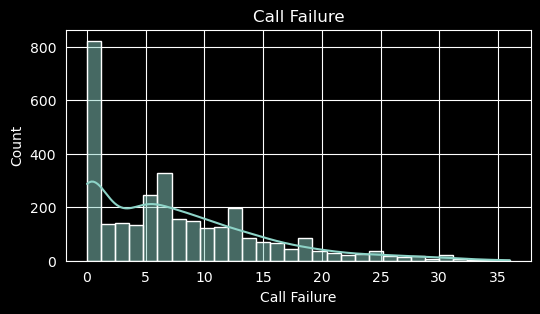

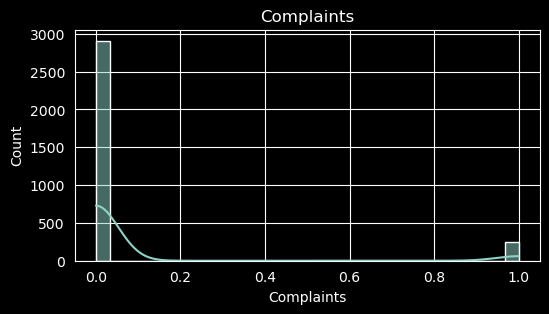

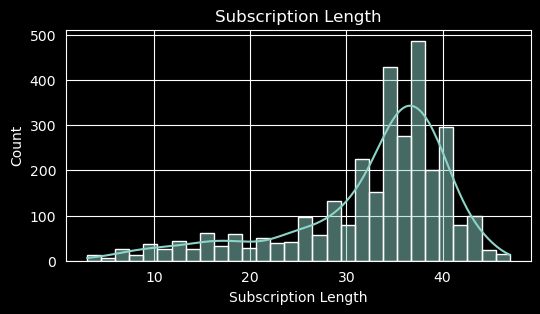

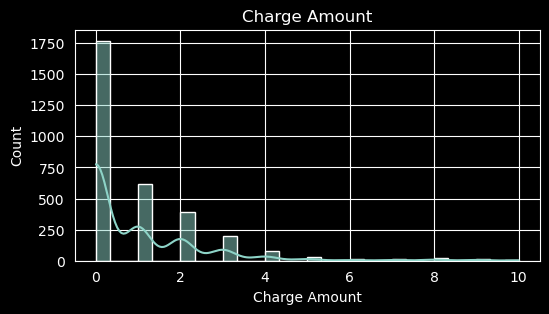

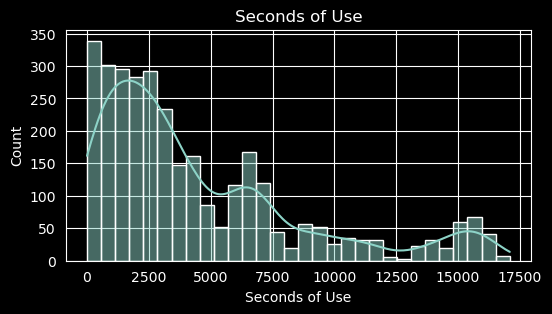

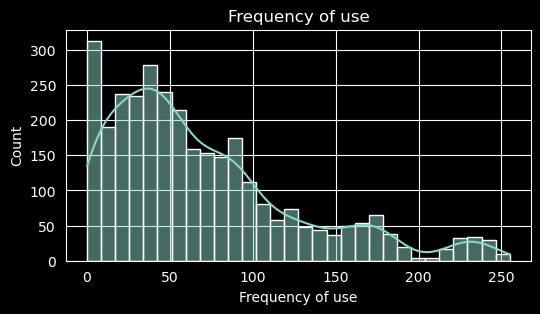

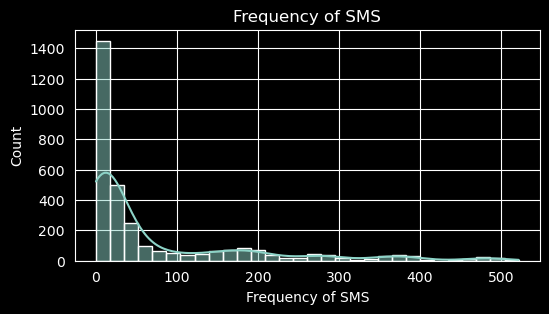

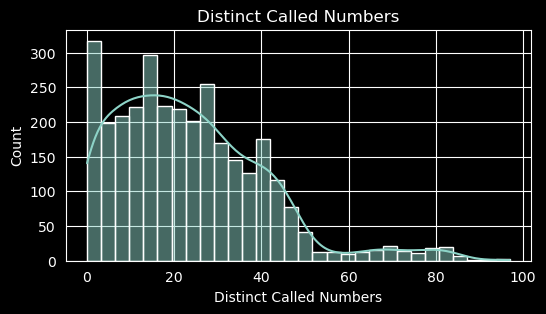

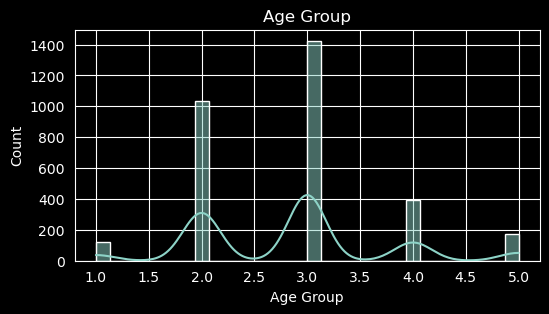

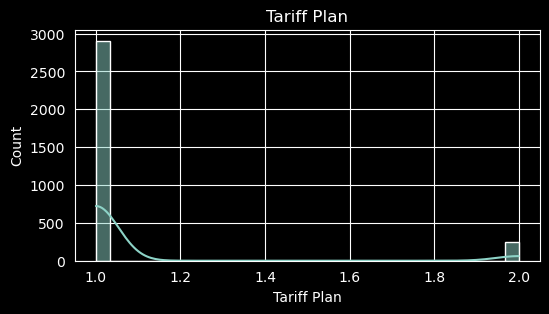

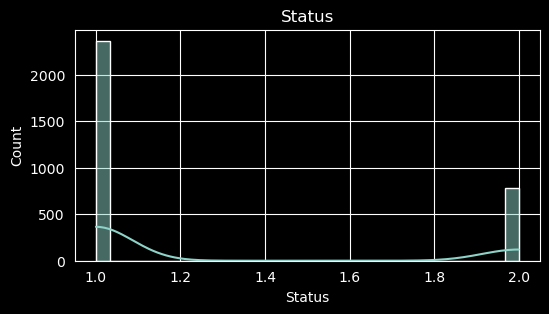

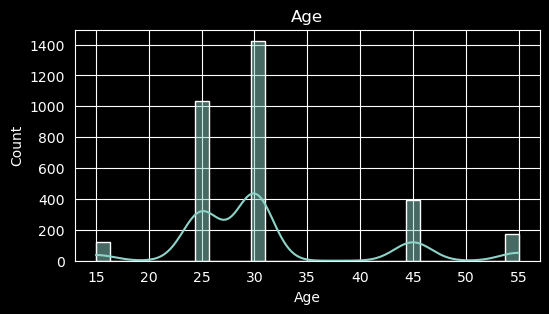

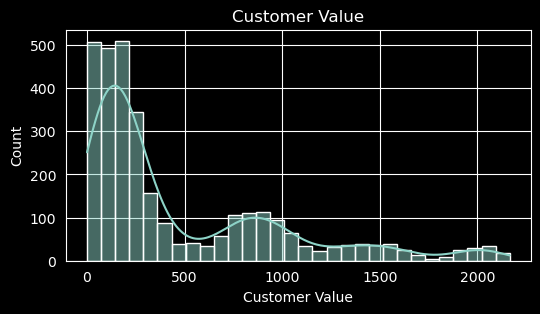

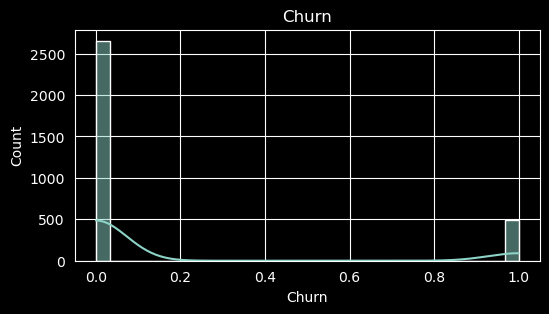

In [23]:
numeric_cols = ["Call Failure", "Complaints", "Subscription Length", "Charge Amount",
                "Seconds of Use", "Frequency of use", "Frequency of SMS", "Distinct Called Numbers",
                "Age Group", "Tariff Plan", "Status", "Age", "Customer Value", "Churn"]

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

In [27]:
df["Charge Amount"].value_counts()

Charge Amount
0     1768
1      617
2      395
3      199
4       76
5       30
8       19
9       14
7       14
6       11
10       7
Name: count, dtype: int64

In [28]:
df["Age Group"].value_counts()

Age Group
3    1425
2    1037
4     395
5     170
1     123
Name: count, dtype: int64

In [29]:
df["Age"].value_counts()

Age
30    1425
25    1037
45     395
55     170
15     123
Name: count, dtype: int64

In [31]:
categorical_cols = ["Complaints", "Charge Amount", "Age","Age Group", "Tariff Plan", "Status", "Churn"]

for col in categorical_cols:
    print(df[col].value_counts())
    print("\n")


Complaints
0    2909
1     241
Name: count, dtype: int64


Charge Amount
0     1768
1      617
2      395
3      199
4       76
5       30
8       19
9       14
7       14
6       11
10       7
Name: count, dtype: int64


Age
30    1425
25    1037
45     395
55     170
15     123
Name: count, dtype: int64


Age Group
3    1425
2    1037
4     395
5     170
1     123
Name: count, dtype: int64


Tariff Plan
1    2905
2     245
Name: count, dtype: int64


Status
1    2368
2     782
Name: count, dtype: int64


Churn
0    2655
1     495
Name: count, dtype: int64




In [32]:
for col in ["Charge Amount", "Seconds of Use", "Frequency of use", "Customer Value"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, ":", outliers.shape[0], "outliers")


Charge Amount : 370 outliers
Seconds of Use : 200 outliers
Frequency of use : 129 outliers
Customer Value : 116 outliers


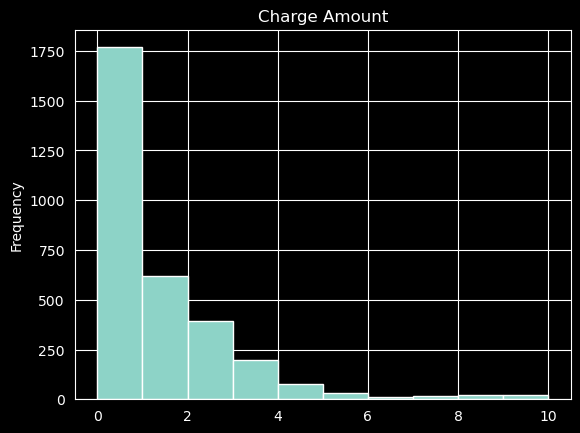

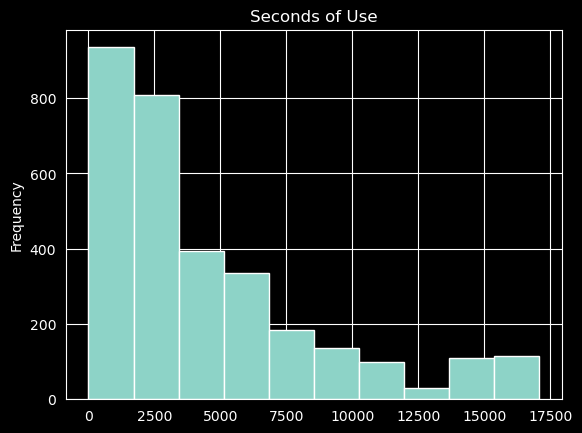

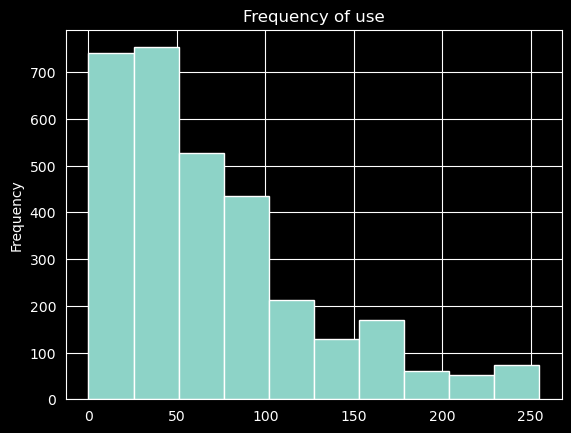

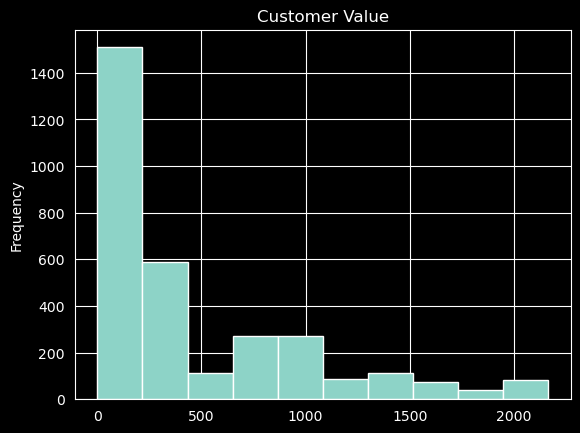

In [34]:
for col in ['Charge Amount', 'Seconds of Use', 'Frequency of use', 'Customer Value']:
    plt.figure()
    df[col].plot(kind='hist')
    plt.title(col)
    plt.show()
